In [1]:
import seaborn as sb
import pingouin as pg
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.style.use('paper_style.mplstyle')



/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# Import and process data

In [2]:
df = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_rest_weighted_5std_all.csv')
info = pd.read_csv('/Volumes/AM_SSD1/Spont2P/Data_info.csv')
df = df.drop(['Unnamed: 0'],axis=1)
df = df.loc[df['Event Rate']>0]
df_reg = df.loc[(df['Baseline']!=-1)&(df['Post']!=-1)]
savepath='/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Figure2-Supp3/plots'

In [ ]:
df['Animal'].loc[df['Group']=='HC'].unique()

array(['994R', '034R', '217N', '218L', '217R', '1912L'], dtype=object)

In [5]:
df['Animal'].loc[df['Group']=='FC'].unique()

array(['989N', '9972R', '149L', '146R', '160R', '493R', '492N'],
      dtype=object)

In [3]:
def calculate_deciles_ani(ani_df):
    animal = ani_df['Animal'].values[0]
    ani_df['Decile']=pd.qcut(ani_df['Event Rate'], 10,labels=False)
    # ani_df['Decile']=ani_df['Decile']+1
    decile_ptagged = [ani_df.loc[(ani_df['Decile']==d)&(ani_df['Population']=='Tagged')].shape[0] 
                  / ani_df.loc[(ani_df['Decile']==d)].shape[0] for d in np.unique(ani_df['Decile'])]
    decile_means = [ani_df['Event Rate'].loc[ani_df['Decile']==d].mean() for d in np.unique(ani_df['Decile'])]
    df = pd.DataFrame()
    df['Animal']=[animal]*10
    df['Decile Mean Rates']=decile_means
    df['P(Tagged)']=decile_ptagged
    return df,ani_df

In [4]:
animals = np.unique(df_reg.Animal)
deciles_rest = pd.DataFrame()
for ani in animals:
    ani_df = df.loc[(df['Animal']==ani)&(df['Session']=='Baseline')].reset_index(drop=True)
    group = info['Group'].loc[info['Animal']==ani].values[0]
    df_ani,cells_df= calculate_deciles_ani(ani_df)
    df_ani['Deciles'] = np.arange(1,11)
    df_ani['Group'] = [group]*10
    deciles_rest = pd.concat([deciles_rest,df_ani],ignore_index=True)

deciles_rest['Decile']=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100']*len(animals)

# Figure 2G Stats

In [5]:
Yrest = [np.mean(deciles_rest['P(Tagged)'].loc[deciles_rest['Deciles']==d].values) for d in np.arange(1,11)]
Xrest = np.arange(0,10)
Xrest = sm.add_constant(Xrest)
modelrest = sm.OLS(Yrest,Xrest)
results_r = modelrest.fit()

pred_ols_r = results_r.get_prediction()
ci_low_r = pred_ols_r.summary_frame()["mean_ci_lower"]
ci_hi_r = pred_ols_r.summary_frame()["mean_ci_upper"]
pval_rest = results_r.f_pvalue
rsq_rest = results_r.rsquared
results_r.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     31.79
Date:                Mon, 04 May 2026   Prob (F-statistic):           0.000488
Time:                        15:04:16   Log-Likelihood:                 22.624
No. Observations:                  10   AIC:                            -41.25
Df Residuals:                       8   BIC:                            -40.64
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2378      0.017     14.368      0.000       0.200       0.276
x1             0.0175      0.003      5.638      0.000       0.010       0.025
==============================================================================
Omnibus:                        1.557   Durbin-Watson:                   2.677
Prob(Omnibus):                  0.459   Jarque-Bera (JB):                0.973
Skew:                          -0.481   Prob(JB):                        0.615
Kurtosis:                       1.812   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

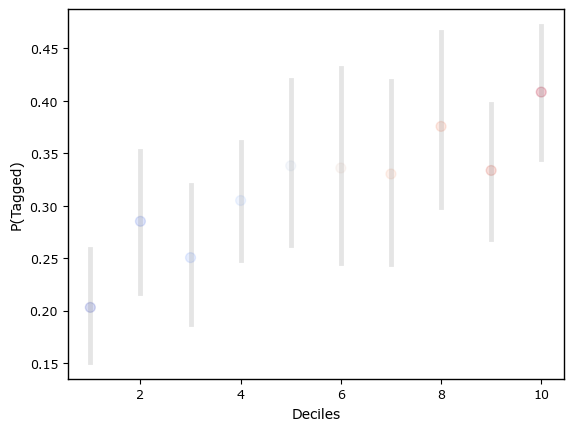

In [6]:
cmap = mpl.cm.get_cmap('coolwarm')
colors = np.linspace(0,1,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=95,fit_reg=False,color='gray',scatter_kws={'alpha':.2,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1})
ax1 = plt.gca()
lower = [line.get_ydata().min() for line in ax1.lines]
upper = [line.get_ydata().max() for line in ax1.lines]
means_rest = ax1.collections[0].get_offsets()[:, 1]
errs_rest = (np.array(upper)-np.array(lower))/2



# Figure 2G Stats

In [7]:
df2  = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_run_weighted_5std_all.csv')
df2 = df2.drop(['Unnamed: 0'],axis=1)
df2 = df2.loc[df2['Event Rate']>0]
df_reg2 = df2.loc[(df2['Baseline']!=-1)&(df2['Post']!=-1)]

animals = np.unique(df_reg2.Animal)
deciles_run = pd.DataFrame()
for ani in animals:
    ani_df = df2.loc[(df2['Animal']==ani)&(df2['Session']=='Baseline')].reset_index(drop=True)
    group = info['Group'].loc[info['Animal']==ani].values[0]
    df_ani,cells_df= calculate_deciles_ani(ani_df)
    df_ani['Deciles'] = np.arange(1,11)
    df_ani['Group'] = [group]*10
    deciles_run = pd.concat([deciles_run,df_ani],ignore_index=True)

deciles_run['Decile']=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100']*len(animals)

Yrun = [np.mean(deciles_run['P(Tagged)'].loc[deciles_run['Deciles']==d].values) for d in np.arange(1,11)]
Xrun = np.arange(0,10)
Xrun = sm.add_constant(Xrun)
modelrun = sm.OLS(Yrun,Xrun)
results_run = modelrun.fit()

pred_ols = results_run.get_prediction()
ci_low_run = pred_ols.summary_frame()["mean_ci_lower"]
ci_hi_run = pred_ols.summary_frame()["mean_ci_upper"]

pval_run=results_run.f_pvalue
rsq_run=results_run.rsquared

results_run.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     3.660
Date:                Mon, 04 May 2026   Prob (F-statistic):             0.0921
Time:                        15:04:16   Log-Likelihood:                 19.136
No. Observations:                  10   AIC:                            -34.27
Df Residuals:                       8   BIC:                            -33.67
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2814      0.023     11.995      0.000       0.227       0.336
x1             0.0084      0.004      1.913      0.092      -0.002       0.019
==============================================================================
Omnibus:                        1.534   Durbin-Watson:                   1.151
Prob(Omnibus):                  0.464   Jarque-Bera (JB):                0.880
Skew:                           0.685   Prob(JB):                        0.644
Kurtosis:                       2.516   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

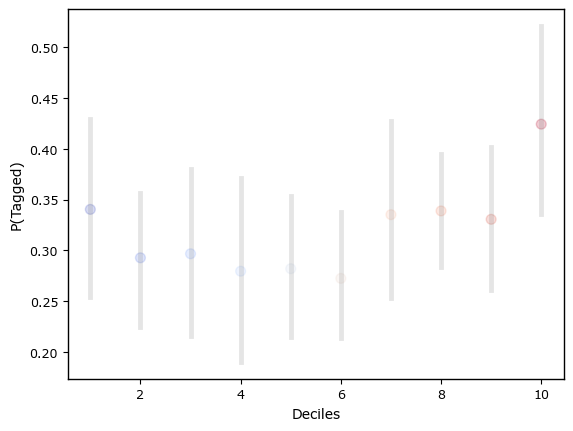

In [8]:
plt.figure()
sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=95,fit_reg=False,color='gray',scatter_kws={'alpha':.2,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1})
ax1 = plt.gca()
lower = [line.get_ydata().min() for line in ax1.lines]
upper = [line.get_ydata().max() for line in ax1.lines]
means_run = ax1.collections[0].get_offsets()[:, 1]
errs_run= (np.array(upper)-np.array(lower))/2

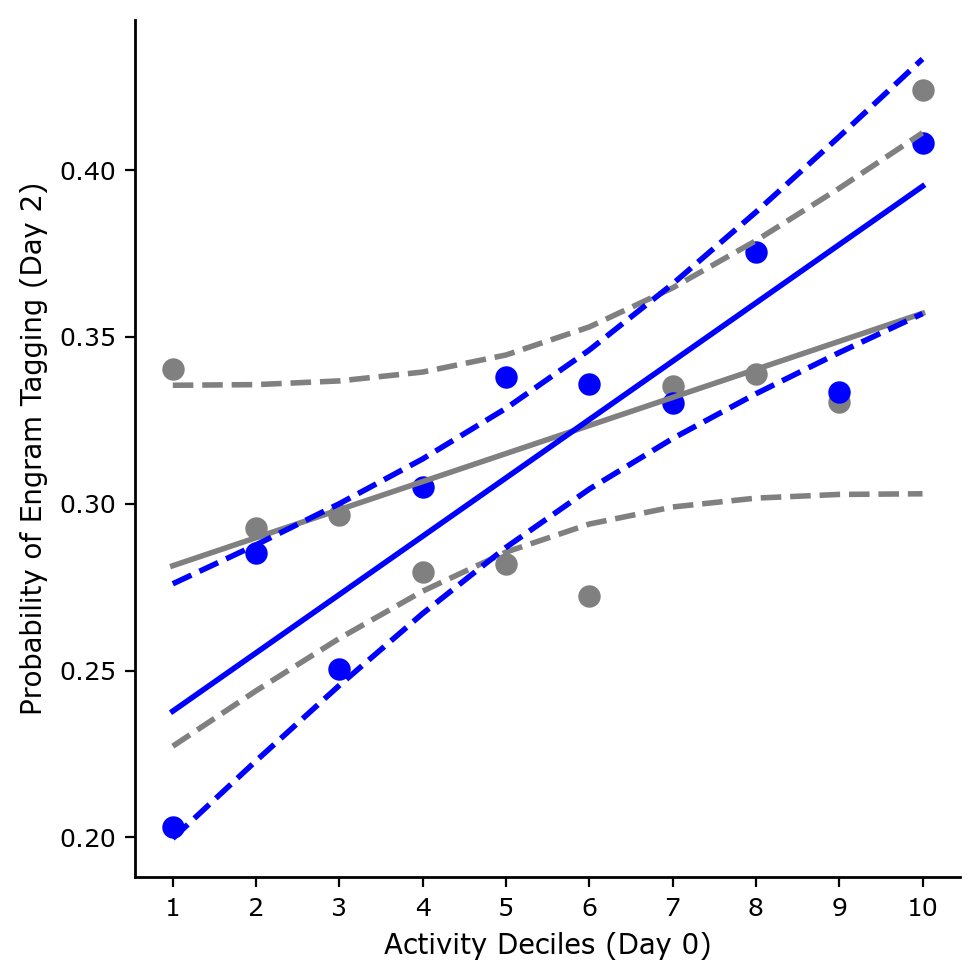

In [9]:
fig,ax=plt.subplots(dpi=200,figsize=(5,5))


#run regression
plt.plot(np.arange(1,11),results_run.fittedvalues,'gray')
plt.plot(np.arange(1,11),ci_low_run,'--',color='gray')
plt.plot(np.arange(1,11),ci_hi_run,'--',color='gray')
sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'linewidths':1})
#sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',fit_reg=False,color='grey',scatter_kws={'s':5})
plt.ylabel('Probability of Engram Tagging (Day 2)')
plt.xlabel('Activity Deciles (Day 0)')
plt.xticks(np.arange(1,11))

#rest regression
plt.plot(np.arange(1,11),results_r.fittedvalues,'blue')
plt.plot(np.arange(1,11),ci_low_r,'--',color='blue')
plt.plot(np.arange(1,11),ci_hi_r,'--',color='blue')
sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='b',scatter_kws={'linewidths':1})
#sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',fit_reg=False,color='grey',scatter_kws={'s':5})
plt.ylabel('Probability of Engram Tagging (Day 2)')
plt.xlabel('Activity Deciles (Day 0)')
plt.xticks(np.arange(1,11))

sb.despine()
plt.tight_layout()

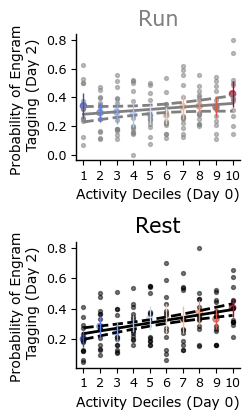

In [10]:

fig,ax=plt.subplots(2,1,figsize=(2.6,4.3))
#run regression lines
ax[0].plot(np.arange(1,11),results_run.fittedvalues,'gray')
ax[0].plot(np.arange(1,11),ci_low_run,'--',color='gray')
ax[0].plot(np.arange(1,11),ci_hi_run,'--',color='gray')
#regression mean points
sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':.7,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1,'s':20},ax=ax[0])
sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',fit_reg=False,color='grey',scatter_kws={'s':8,'alpha':0.5},ax=ax[0]) #all points
ax[0].errorbar(np.arange(1,11),means_run,yerr=errs_run,linewidth=1,ecolor=tencolors,linestyle='') #error bars 
ax[0].set_ylabel('Probability of Engram \n Tagging (Day 2)',size=10)
#ax[0].set_ylim([.25,.45])
ax[0].set_xlabel('Activity Deciles (Day 0)',size=10)
ax[0].set_xticks(np.arange(1,11),size=8)
ax[0].set_title('Run',color='gray')

#rest regression lines
ax[1].plot(np.arange(1,11),results_r.fittedvalues,'k')
ax[1].plot(np.arange(1,11),ci_low_r,'--',color='k')
ax[1].plot(np.arange(1,11),ci_hi_r,'--',color='k')
#regression mean points
sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='k',scatter_kws={'alpha':.7,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1,'s':20},ax=ax[1])
sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',fit_reg=False,color='k',scatter_kws={'s':8,'alpha':.5},ax=ax[1]) #all data points
ax[1].errorbar(np.arange(1,11),means_rest,yerr=errs_rest,linewidth=1,ecolor=tencolors,linestyle='') #error bars 
ax[1].set_ylabel('Probability of Engram \n Tagging (Day 2)',size=10)
#ax[1].set_ylim([.25,.45])
ax[1].set_xlabel('Activity Deciles (Day 0)',size=10)
ax[1].set_xticks(np.arange(1,11),size=8)
ax[1].set_title('Rest',color='k')

sb.despine()
plt.tight_layout()
plt.savefig('deciles_baselinerate_ptag_all_restandrun.svg',transparent=True)

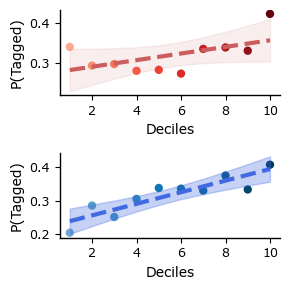

In [11]:
fig,ax=plt.subplots(figsize=(3,3),ncols=1,nrows=2)
cmap = mpl.cm.get_cmap('Reds')
colors = np.linspace(.3,1,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1,'s':25},ax=ax[0])
ax[0].plot(np.arange(1,11),results_run.fittedvalues,'indianred',linewidth=3,linestyle='--')
# ax.plot(np.arange(1,11),ci_low_run,'--',color='gray',linewidth=2,alpha=.5)
# ax.plot(np.arange(1,11),ci_hi_run,'--',color='gray',linewidth=2,alpha=.5)
ax[0].fill_between(np.arange(1,11), ci_low_run, ci_hi_run, color='indianred', alpha=0.1, label='Error Band')  # Error band

cmap = mpl.cm.get_cmap('PuBu')
colors = np.linspace(.5,1,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='k',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':1,'s':25},ax=ax[1])
ax[1].plot(np.arange(1,11),results_r.fittedvalues,'royalblue',linewidth=3,linestyle='--')
# ax.plot(np.arange(1,11),ci_low_r,'--',color='k',linewidth=2,alpha=.5)
# ax.plot(np.arange(1,11),ci_hi_r,'--',color='k',linewidth=2,alpha=.5)
ax[1].fill_between(np.arange(1,11), ci_low_r, ci_hi_r, color='royalblue', alpha=0.3, label='Error Band')  # Error band
plt.tight_layout()
sb.despine()
plt.savefig('rest_v_run_avmice_reglines.svg',transparent=True)

# Figure 2G

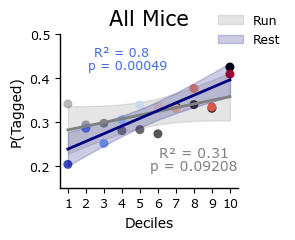

In [12]:
fig,ax=plt.subplots(figsize=(2.3,2))
cmap = mpl.cm.get_cmap('Greys')
colors = np.linspace(.4,1,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':2,'s':20},ax=ax)
ax.plot(np.arange(1,11),results_run.fittedvalues,'gray',linewidth=2,linestyle='-')
ax.fill_between(np.arange(1,11), ci_low_run, ci_hi_run, color='gray', alpha=0.2, label='Run')  # Error band

plt.text(8,.22,f"R\u00b2 = {np.round(rsq_run,2)}",ha='center',size=10,color='gray')
plt.text(8,.19,f"p = {np.round(pval_run,5):.5f}",ha='center',size=10,color='gray')

cmap = mpl.cm.get_cmap('coolwarm')
colors = np.linspace(0,1,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='k',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':2,'s':20},ax=ax)
ax.plot(np.arange(1,11),results_r.fittedvalues,'navy',linewidth=2,linestyle='-')
ax.fill_between(np.arange(1,11), ci_low_r, ci_hi_r, color='navy', alpha=0.2, label='Rest')  # Error band
ax.set_xticks(np.arange(1, 11))

plt.text(4,.45,f"R\u00b2 = {np.round(rsq_rest,2)}",ha='center',size=9,color='royalblue')
plt.text(4.3,.42,f"p = {np.round(pval_rest,5):.5f}",ha='center',size=9,color='royalblue')
plt.title('All Mice')
plt.ylim([.15,.5])
plt.legend(bbox_to_anchor=(1.3,1.2),frameon=False,fontsize=9)
sb.despine()
plt.savefig(f'Figure2G_rest_v_run_avmice_reglines_overlaid.svg',transparent=True)